# Object-Oriented Programming in C++ — 2310261L
### How CO1 and CO2 are used in Datapath Bench

Object orientation here is structural. Remove it and the design does not hold together.

| | Outcome | Used for |
|---|---|---|
| **CO1** | Develop solutions using object-oriented programming | Classes that each own their own state |
| **CO2** | Choose an appropriate solution to reduce complexity | One class per instruction, instead of a branch chain |

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch, Circle

PAPER  = "#FAF8F3"; BAND = "#F1EEE6"
NAVY   = "#1B2A34"; INK  = "#1C2320"
COPPER = "#B25E1C"; TEAL = "#0C5E50"
LINE   = "#C9C2B2"; MUTED = "#7C8781"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9})

def canvas(w=11, h=3.2, xlim=(0, 110), ylim=(0, 32)):
    fig, ax = plt.subplots(figsize=(w, h), dpi=150)
    fig.patch.set_facecolor(PAPER); ax.set_facecolor(PAPER)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    return fig, ax

def box(ax, x, y, w, h, title="", sub="", fc="white", ec=None, tc=None, fs=9, r=0.4):
    ec = ec or LINE; tc = tc or INK
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=%s" % r,
                 linewidth=1.3, edgecolor=ec, facecolor=fc, zorder=2))
    if title:
        ax.text(x + w/2, y + h/2 + (1.4 if sub else 0), title, ha="center", va="center",
                fontsize=fs, color=tc, weight="bold", zorder=3)
    if sub:
        ax.text(x + w/2, y + h/2 - 2.0, sub, ha="center", va="center",
                fontsize=fs-1.6, color=MUTED, zorder=3)

def arrow(ax, x1, y1, x2, y2, color=None, lw=1.4, style="-|>", ls="-"):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style,
                 mutation_scale=11, linewidth=lw, color=color or MUTED,
                 linestyle=ls, zorder=4, shrinkA=1, shrinkB=1))

def label(ax, x, y, t, color=None, fs=8.2, ha="center", weight="normal", style="normal"):
    ax.text(x, y, t, ha=ha, va="center", fontsize=fs,
            color=color or MUTED, weight=weight, style=style, zorder=5)

print('diagram helpers ready')

diagram helpers ready


---
## CO1 · Develop solutions using object-oriented programming

Each class owns its own data, and nothing outside can reach it directly.

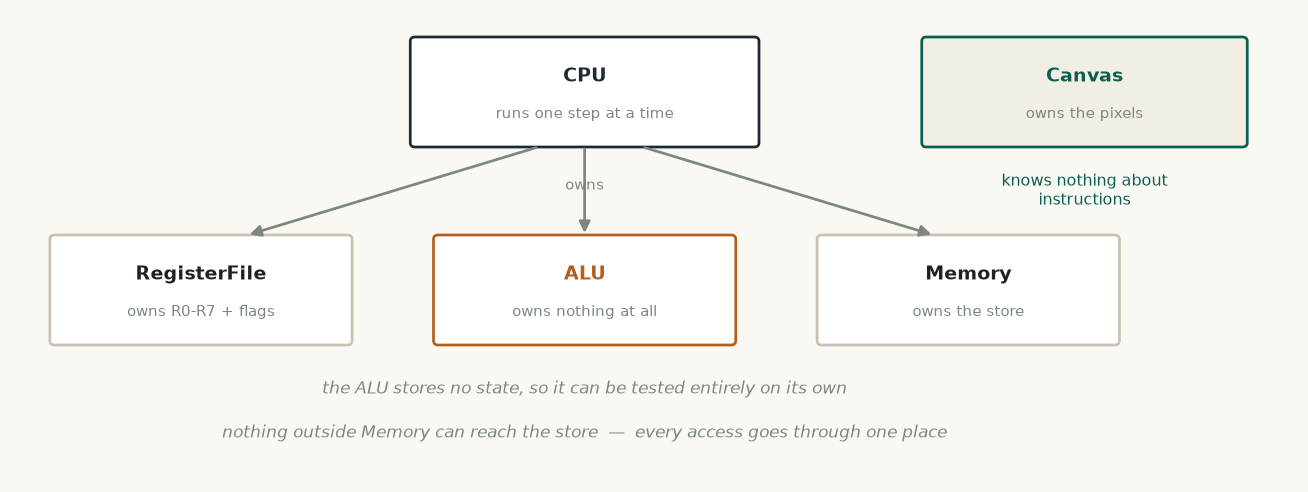

In [ ]:
fig, ax = canvas(h=4.0, ylim=(0, 42))
box(ax, 34, 30, 30, 10, "CPU", "runs one step at a time", fc="white", ec=NAVY, tc=NAVY)
box(ax, 3,  12, 26, 10, "RegisterFile", "owns R0-R7 + flags", fc="white")
box(ax, 36, 12, 26, 10, "ALU", "owns nothing at all", fc="white", ec=COPPER, tc=COPPER)
box(ax, 69, 12, 26, 10, "Memory", "owns the store", fc="white")
box(ax, 78, 30, 28, 10, "Canvas", "owns the pixels", fc=BAND, ec=TEAL, tc=TEAL)
arrow(ax, 45, 30, 20, 22, MUTED, 1.3)
arrow(ax, 49, 30, 49, 22, MUTED, 1.3)
arrow(ax, 54, 30, 79, 22, MUTED, 1.3)
label(ax, 49, 26.5, "owns", fs=7.4)
label(ax, 92, 26, "knows nothing about\ninstructions", color=TEAL, fs=7.6)
label(ax, 49, 8, "the ALU stores no state, so it can be tested entirely on its own", fs=8.2, style="italic")
label(ax, 49, 4, "nothing outside Memory can reach the store  \u2014  every access goes through one place",
      fs=8.2, style="italic")
plt.show()

| Class | Owns | Responsible for |
|---|---|---|
| `RegisterFile` | the registers and flag | reads, writes, reporting what changed |
| `ALU` | nothing at all | given an operation and two values, return a result and flags |
| `Memory` | the addressable store | reads and writes by address, nothing else |
| `CPU` | registers, ALU, memory, program | running one step, keeping state consistent |
| `Canvas` | the pixel buffer | turning coordinates into pixels |

Because the ALU stores no state it can be tested completely on its own. Because the
Canvas knows nothing about instructions, the console interface could be swapped for a
graphical one without touching the engine.

---
## CO2 · Choose an appropriate solution to reduce complexity

Our processor understands fifteen instructions. There are two ways to handle that.

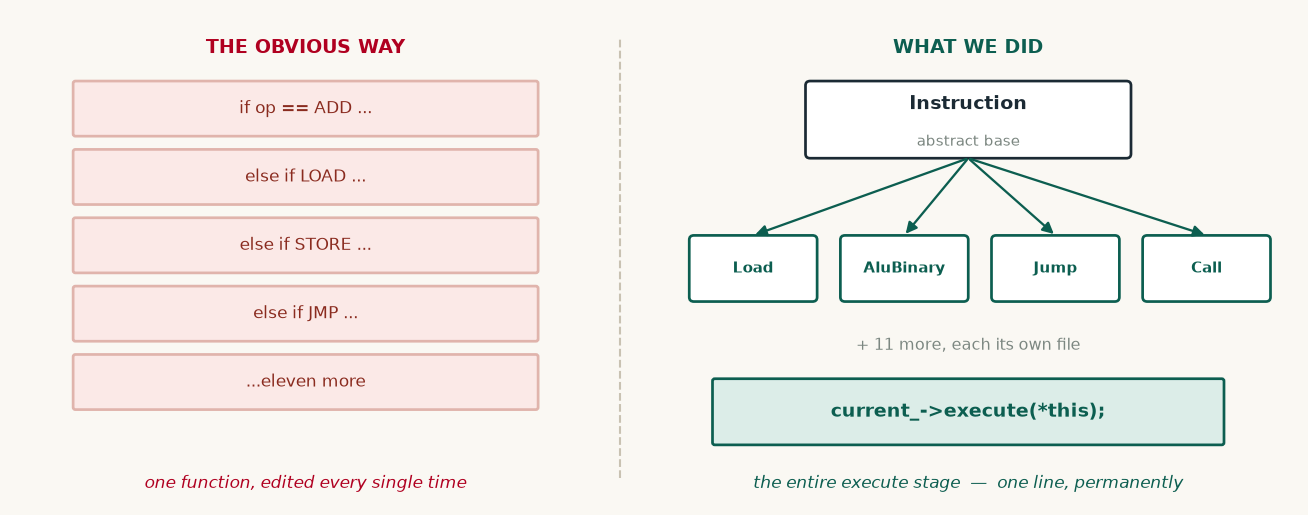

In [ ]:
fig, ax = canvas(h=4.2, ylim=(0, 44))
label(ax, 25, 41, "THE OBVIOUS WAY", color="#B00020", fs=9.3, weight="bold")
for i, t in enumerate(["if op == ADD ...", "else if LOAD ...", "else if STORE ...",
                       "else if JMP ...", "...eleven more"]):
    box(ax, 5, 33 - i*6.2, 40, 5, "", "", fc="#FBE9E7", ec="#E0B4AC", r=0.2)
    label(ax, 25, 35.5 - i*6.2, t, color="#8A2B1F", fs=8)
label(ax, 25, 1.5, "one function, edited every single time", color="#B00020", fs=8.2, style="italic")
ax.plot([52, 52], [2, 42], color=LINE, lw=1, ls="--")
label(ax, 82, 41, "WHAT WE DID", color=TEAL, fs=9.3, weight="bold")
box(ax, 68, 31, 28, 7, "Instruction", "abstract base", fc="white", ec=NAVY, tc=NAVY)
for i, n in enumerate(["Load", "AluBinary", "Jump", "Call"]):
    box(ax, 58 + i*13, 18, 11, 6, n, "", fc="white", ec=TEAL, tc=TEAL, fs=7.4)
    arrow(ax, 82, 31, 63.5 + i*13, 24, TEAL, 1.1)
label(ax, 82, 14, "+ 11 more, each its own file", fs=7.6)
box(ax, 60, 5, 44, 6, "", "", fc="#DCEDE8", ec=TEAL, r=0.2)
label(ax, 82, 8, "current_->execute(*this);", color=TEAL, fs=9, weight="bold")
label(ax, 82, 1.5, "the entire execute stage  \u2014  one line, permanently", color=TEAL, fs=8.2, style="italic")
plt.show()

```cpp
class Instruction {                       // one base they all share
public:
    virtual ~Instruction() {}
    virtual void execute(CPU& cpu) = 0;   // each subclass fills this in
};

// ...and inside the processor, the entire execute stage is:
current_->execute(*this);      // no idea, and no need to know, which instruction
```

| Measure | Branch chain | Class per instruction |
|---|---|---|
| Adding an instruction | edit the processor's central function | add one file, processor untouched |
| Length of that function | grows with every instruction | one line, permanently |
| Risk when changing | every instruction shares one function | each instruction is isolated |

Templates matter for the same reason. One `Stack<T>` serves both the call stack
(`Stack<Word>`) and the expression evaluator (`Stack<char>`) — one implementation, two
unrelated types, checked by the compiler each time.

---
## Held back for later parts

This notebook covers **CO1 and CO2 only** — the deliberate scope of the first working
prototype. The remaining outcomes are planned work, listed here so the omission reads
as planning rather than a gap.

The remaining practicals — operator overloading, exceptions, `std::move`, STL and
type casting — are already present in the codebase and are documented in
`docs/subjects/04-object-oriented-cpp.md`.

*Note: the official CO wording for 2310261L should be confirmed against the syllabus.
The mapping of work to concepts is unaffected either way.*

---
*Datapath Bench — an integrated SY B.Tech project.*
*Vivek Dhamale · Pranjal Bhandari · Sanika Patil · Mrudula Bongulwar.*
*Guide: Mrs. Jaya S. Mane, Assistant Professor, Software Engineering Department.*